In [1]:
!git clone https://github.com/RudraKsh0091/AI-Image-Impainting.git
%cd AI-Image-Impainting
!pip install -r requirements.txt

Cloning into 'AI-Image-Impainting'...
remote: Enumerating objects: 179, done.
remote: Counting objects: 100% (179/179), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 179 (delta 99), reused 109 (delta 44), pack-reused 0 (from 0)
Receiving objects: 100% (179/179), 3.29 MiB | 26.97 MiB/s, done.
Resolving deltas: 100% (99/99), done.
Filtering content: 100% (4/4), 1.25 GiB | 28.84 MiB/s, done.
/kaggle/working/AI-Image-Impainting


2026-06-22 13:14:43.436488: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782134083.686902      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782134083.745500      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782134084.283178      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782134084.283252      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782134084.283257      58 computation_placer.cc:177] computation placer alr

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


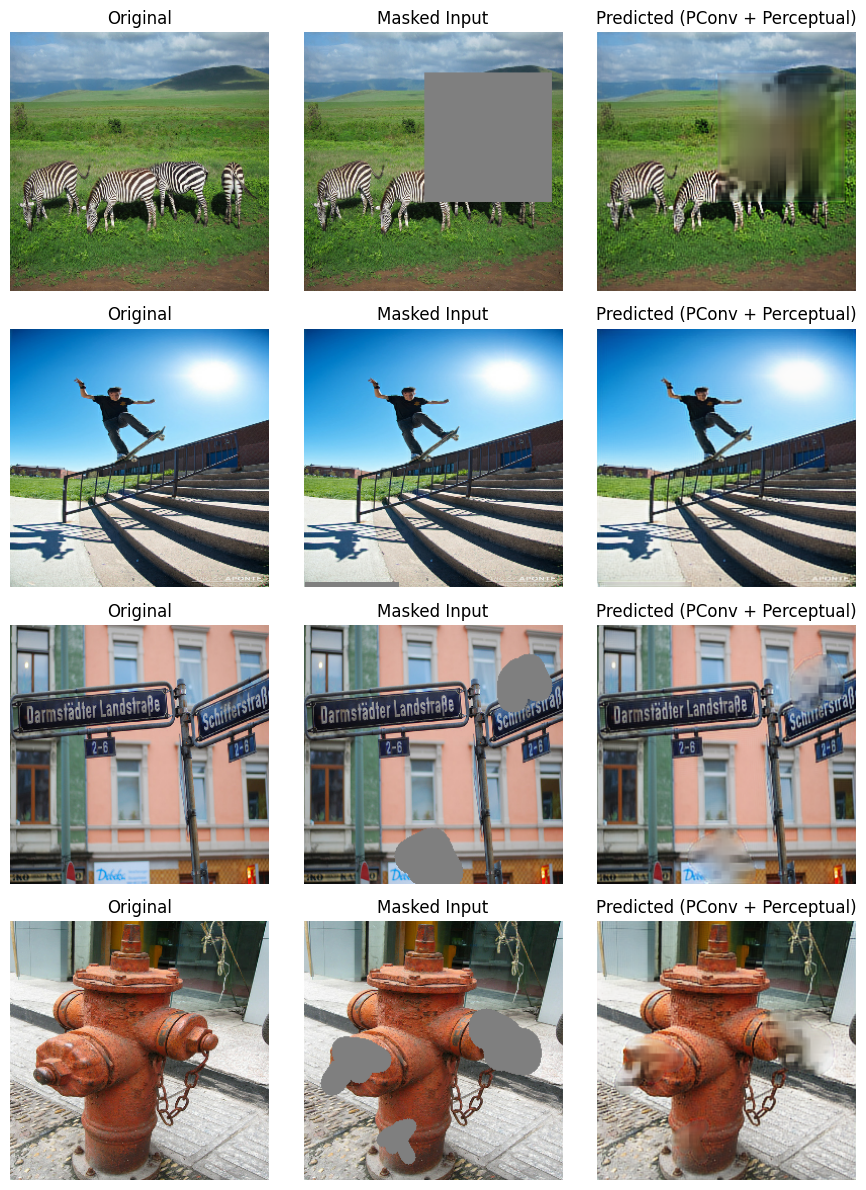

In [3]:
import sys
sys.path.insert(0, '/kaggle/working/AI-Image-Impainting')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from src.model import build_pconv_unet
from src.data import get_train_val_split, load_dataset
from src import config

# Load model
model = build_pconv_unet(img_size=config.IMG_SIZE)
model.load_weights("models/best_model_pconv_perceptual.weights.h5", skip_mismatch=True)

# Load same validation data as before
_, val_paths = get_train_val_split(config.IMAGE_DIR, num_train=config.NUM_TRAIN, num_val=config.NUM_VAL)
val_ds = load_dataset(val_paths[:8], img_size=config.IMG_SIZE, batch_size=8, mask_type='combined', fixed_seed=123)

# Get one batch
for (masked_images, masks), originals in val_ds.take(1):
    predictions = model.predict([masked_images, masks])
    break

# Denormalize
def denormalize_image(img):
    img = (img + 1.0) * 127.5
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

# Plot
num_samples = 4
fig, axes = plt.subplots(num_samples, 3, figsize=(9, num_samples * 3))

for i in range(num_samples):
    original = denormalize_image(originals[i].numpy())
    masked = denormalize_image(masked_images[i].numpy())
    predicted = denormalize_image(predictions[i])

    axes[i, 0].imshow(original)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(masked)
    axes[i, 1].set_title("Masked Input")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(predicted)
    axes[i, 2].set_title("Predicted (PConv + Perceptual)")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("evaluation_grid_pconv_perceptual.png", dpi=150)
plt.show()